In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# This is our 'Brain Engine'
def simulate_decision(v, s, threshold=1.0, dt=0.01):
    evidence, time = 0, 0
    while abs(evidence) < threshold and time < 3.0:
        evidence += v * dt + s * np.sqrt(dt) * np.random.normal()
        time += dt
    return time

print("Brain Engine Loaded!")


Brain Engine Loaded!


In [3]:
def run_experiment(strategy):
    rts = []
    v, s = 0.8, 0.2  # Starting fresh (Fast speed, Low noise)
    for trial in range(1000):
        # The fatigue 'drain' - Speed drops, Noise rises
        v = max(0.1, v - 0.0005) 
        s = s + 0.0008           
        
        # Applying the recovery strategy
        if strategy == "micro-breaks" and trial % 100 == 0:
            s = max(0.2, s - 0.1) # Reset noise slightly
        elif strategy == "long-rest" and trial == 500:
            v, s = 0.8, 0.2       # Full reset halfway
            
        rts.append(simulate_decision(v, s))
    return rts

# Execute the 'Participants'
group_a = run_experiment("no-rest")
group_b = run_experiment("micro-breaks")
group_c = run_experiment("long-rest")
print("Experiment Finished!")


Experiment Finished!


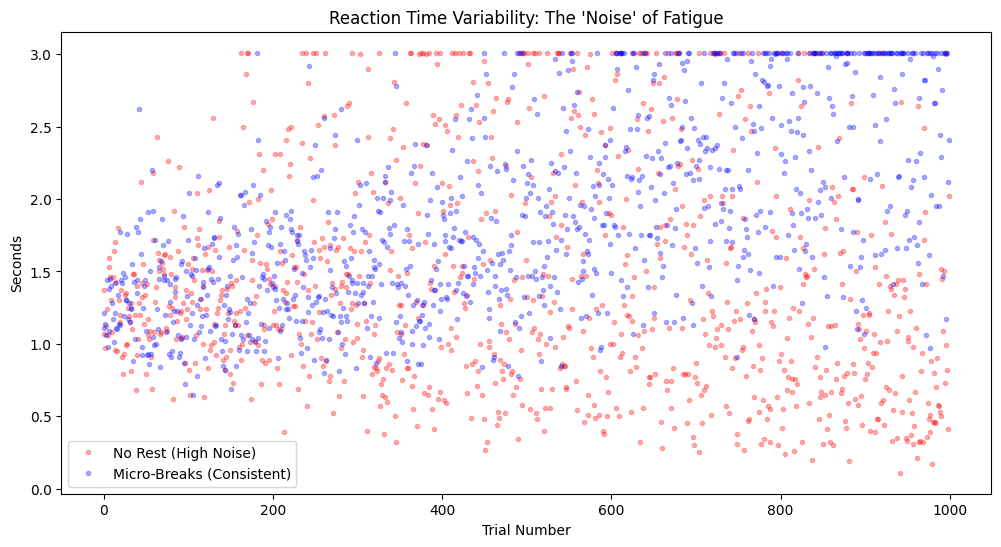

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(group_a, 'r.', alpha=0.3, label="No Rest (High Noise)")
plt.plot(group_b, 'b.', alpha=0.3, label="Micro-Breaks (Consistent)")
plt.title("Reaction Time Variability: The 'Noise' of Fatigue")
plt.ylabel("Seconds")
plt.xlabel("Trial Number")
plt.legend()
plt.show()


In [5]:
def get_report(data, name):
    # Standard Deviation is the 'Noise' metric
    noise_level = np.std(data)
    # Lapses are trials where it took longer than 0.5 seconds
    lapses = sum(1 for x in data if x > 0.5)
    
    print(f"--- {name} Report ---")
    print(f"Behavioral Noise (SD): {noise_level:.3f}")
    print(f"Total Cognitive Lapses: {lapses}")
    print("-" * 20)

get_report(group_a, "Group A (No Rest)")
get_report(group_b, "Group B (Micro-Breaks)")
get_report(group_c, "Group C (Long Rest)")


--- Group A (No Rest) Report ---
Behavioral Noise (SD): 0.762
Total Cognitive Lapses: 923
--------------------
--- Group B (Micro-Breaks) Report ---
Behavioral Noise (SD): 0.660
Total Cognitive Lapses: 1000
--------------------
--- Group C (Long Rest) Report ---
Behavioral Noise (SD): 0.653
Total Cognitive Lapses: 985
--------------------


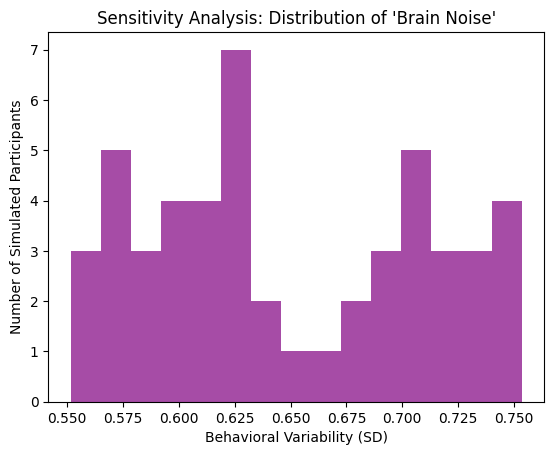

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. NEW ENGINE: Added Motivation (m)
def simulate_adv_decision(v, s, m, threshold=1.0, dt=0.01):
    evidence, time = 0, 0
    # Processing speed is now scaled by motivation
    effective_v = v * m 
    while abs(evidence) < threshold and time < 3.0:
        evidence += effective_v * dt + s * np.sqrt(dt) * np.random.normal()
        time += dt
    return time

# 2. SENSITIVITY ANALYSIS: Running 50 'Participants'
def run_sensitivity_check(trials=500):
    results = []
    # We test 50 different 'fatigue strengths'
    for participant in range(50):
        # Randomly vary how fast they get tired
        drain_rate = np.random.uniform(0.0003, 0.0008)
        rts = []
        v, s, m = 0.8, 0.2, 1.0 # Motivation starts at 100%
        
        for t in range(trials):
            v -= drain_rate
            s += drain_rate * 1.5
            m -= 0.0002 # Motivation slowly drops from boredom
            rts.append(simulate_adv_decision(v, s, m))
        
        results.append(np.std(rts)) # Store the 'Noise' (SD) for this person
    return results

# Run it!
noise_distribution = run_sensitivity_check()

# 3. VISUALIZE SENSITIVITY
plt.hist(noise_distribution, bins=15, color='purple', alpha=0.7)
plt.title("Sensitivity Analysis: Distribution of 'Brain Noise'")
plt.xlabel("Behavioral Variability (SD)")
plt.ylabel("Number of Simulated Participants")
plt.show()
